<i>## Comments will be provided using this format. Key takeaway: groups are encouraged to change the formatting, but not the structure. Groups are also allowed to create additional notebooks - for instance, create one notebook for data exploration, and one notebook for each preprocessing-modelling-evaluation pipeline -, but must strive to keep an unified style across notebooks.</i>

#### NOVA IMS / BSc in Data Science / Text Mining 2025/2026
### <b>Group Project: "Straining the great southern Melting Pot"</b>
#### Notebook `Notebook Title`

#### Group:
- `Group member #1`
- `(...)`
- `Group member #5`

#### <font color='#BFD72'>Table of Contents </font> <a class="anchor" id='toc'></a> 
- [1. Data Understanding](#P1)
- [2. General Data Preparation](#P2) 
- [3. Multilabel Classification (Information Requirement 3311)](#P3)
    - [3.1 Specific Data Preparation](#P31)
    - [3.2 Model Implementation](#P32)
    - [3.3 Model Evaluation](#P3n)
- [4. Sentiment Analysis (Information Requirement 3312)](#P4)
    - [4.1 Specific Data Preparation](#P41)
    - [4.2 Model Implementation](#P42)
    - [4.3 Model Evaluation](#P43)
- [...]
- [N. Additional Tasks (Information Requirements 332n)](#Pn)
    - [N.1 Specific Data Preparation](#Pn1)
    - [N.2 Model Implementation](#Pn2)
    - [N.3 Model Evaluation](#Pn3)

<i>## Note that the notebook structure differs from the report: instead of following the CRISP-DM phases and then specifying the different problems inside the phases, the notebook is structured by problem, with the CRISP-DM phases being defined for each specific problem.

In [68]:
## All imports must be concentrated on a cell that immediately follow the table of contents
import time
import pandas as pd
import nltk
import utils
import numpy as np

from nltk.tokenize import PunktSentenceTokenizer

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

from nltk.sentiment.vader import SentimentIntensityAnalyzer
from textblob import TextBlob

from wordcloud import WordCloud

from scipy.stats import pearsonr
from sklearn import preprocessing
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

<font color='#BFD72F' size=5>1. Data Understanding</font> <a class="anchor" id="P1"></a>
  
[Back to TOC](#toc)

<i>## Use markdown cells to describe the purpose of the code cells that follow them.</i>

In [5]:
## Functions must be defined on separate cells
def text_mining_project_simulator():
    project_progress = 0
    while project_progress < 100:
        ## Comments on code cells can be used to highlight specific sections of yout code
        project_progress += 1
        print("working, albeit reluctantly, on a project that's {}% done \n\n".format(project_progress))
        time.sleep(5)

In [ ]:
## Calls to functions (whether defined by the group, or imported from packages) must be separate from their definition

text_mining_project_simulator()

<font color='#BFD72F' size=5>2. General Data Preparation</font> <a class="anchor" id="P1"></a>

<font color='#BFD72F' size=5>3. Multilabel Classification</font> <a class="anchor" id="P1"></a>

<font color='#BFD72F' size=5>4. Sentiment Analysis</font> <a class="anchor" id="P1"></a>

Goal: How strong is the relationship between the polarity of a comments and its score?

In [3]:
dataset_sent = pd.read_csv(r"data_atlanta\atlanta_restaurant_slice_2023.csv")
dataset_sent.head()

,title,categoryName,website,url,reviewsCount,stars,text
0,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,"One word amazing!! The red fish, halibut, fr..."
1,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,First time here and the food is great and the ...
2,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,I recently had the pleasure of dining at Optim...
3,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,Beautiful atmosphere and delicious food. All o...
4,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,We had a wonderful dinner at the Optimist. Our...


In [4]:
dataset_sent.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53566 entries, 0 to 53565
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         53566 non-null  object 
 1   categoryName  53566 non-null  object 
 2   website       50600 non-null  object 
 3   url           53566 non-null  object 
 4   reviewsCount  53566 non-null  int64  
 5   stars         53566 non-null  float64
 6   text          53566 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 2.9+ MB


In [5]:
dataset_sent.describe()

,reviewsCount,stars
count,53566.000000,53566.000000
mean,917.447355,4.050498
std,1129.721892,1.448570
min,5.000000,1.000000
25%,404.000000,3.000000
50%,644.000000,5.000000
75%,1051.250000,5.000000
max,13268.000000,5.000000


In [6]:
dataset_sent.drop(["title", "categoryName", "website", "url"], axis=1, inplace=True)

In [7]:
dataset_sent["text"].iloc[18090]

'Food was good just a bit salty for me.\nService was great with good recommendations.'

In [8]:
dataset_sent["text"].iloc[1909]

'In the Buckhead area a very particular and unusual ambience.  Great and extensive wine selection.  Flavourful and interesting meal selections.  Shape up your Italian!'

Preprocessing analysis:
- newlins


In [9]:
class Example():
    def __init__(self, example_row) -> None:
        self.index = example_row.index[0]
        self.score = example_row["stars"].values[0]
        self.raw_content = example_row["text"].values[0]

In [10]:
help(CountVectorizer)

Help on class CountVectorizer in module sklearn.feature_extraction.text:

class CountVectorizer(_VectorizerMixin, sklearn.base.BaseEstimator)
 |  CountVectorizer(*, input='content', encoding='utf-8', decode_error='strict', strip_accents=None, lowercase=True, preprocessor=None, tokenizer=None, stop_words=None, token_pattern='(?u)\\b\\w\\w+\\b', ngram_range=(1, 1), analyzer='word', max_df=1.0, min_df=1, max_features=None, vocabulary=None, binary=False, dtype=<class 'numpy.int64'>)
 |  
 |  Convert a collection of text documents to a matrix of token counts.
 |  
 |  This implementation produces a sparse representation of the counts using
 |  scipy.sparse.csr_matrix.
 |  
 |  If you do not provide an a-priori dictionary and you do not use an analyzer
 |  that does some kind of feature selection then the number of features will
 |  be equal to the vocabulary size found by analyzing the data.
 |  
 |  For an efficiency comparison of the different feature extractors, see
 |  :ref:`sphx_glr_au

In [11]:
help(WordCloud)

Help on class WordCloud in module wordcloud.wordcloud:

class WordCloud(builtins.object)
 |  WordCloud(font_path=None, width=400, height=200, margin=2, ranks_only=None, prefer_horizontal=0.9, mask=None, scale=1, color_func=None, max_words=200, min_font_size=4, stopwords=None, random_state=None, background_color='black', max_font_size=None, font_step=1, mode='RGB', relative_scaling='auto', regexp=None, collocations=True, colormap=None, normalize_plurals=True, contour_width=0, contour_color='black', repeat=False, include_numbers=False, min_word_length=0, collocation_threshold=30)
 |  
 |  Word cloud object for generating and drawing.
 |  
 |  Parameters
 |  ----------
 |  font_path : string
 |      Font path to the font that will be used (OTF or TTF).
 |      Defaults to DroidSansMono path on a Linux machine. If you are on
 |      another OS or don't have this font, you need to adjust this path.
 |  
 |  width : int (default=400)
 |      Width of the canvas.
 |  
 |  height : int (defaul

In [12]:
bow_vectorizer = CountVectorizer(token_pattern=r"(?u)\b\w+\b", lowercase=True, stop_words="english")
bow_td_matrix = bow_vectorizer.fit_transform(dataset_sent["text"]).toarray()
dataset_sent["initial_bow_vector"] = list(bow_td_matrix)
bow_word_list = bow_vectorizer.get_feature_names_out()

In [13]:
bow_td_matrix.shape #it has 26154 unique words

(53566, 26154)

In [14]:
bow_word_list #chinese?

array(['0', '00', '000', ..., '했고', '확', '힐라피뇨도'], dtype=object)

In [15]:
raw_vocab = utils.word_freq_calculator(bow_td_matrix, bow_word_list, df_output=False)

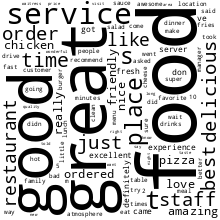

In [16]:
wc = WordCloud(background_color="white",max_words=120, width = 220,height = 220, color_func=lambda *args, **kwargs: (0,0,0))
wc.generate_from_frequencies(raw_vocab)
wc.to_image()

In [17]:
help(TfidfVectorizer)

Help on class TfidfVectorizer in module sklearn.feature_extraction.text:

class TfidfVectorizer(CountVectorizer)
 |  TfidfVectorizer(*, input='content', encoding='utf-8', decode_error='strict', strip_accents=None, lowercase=True, preprocessor=None, tokenizer=None, analyzer='word', stop_words=None, token_pattern='(?u)\\b\\w\\w+\\b', ngram_range=(1, 1), max_df=1.0, min_df=1, max_features=None, vocabulary=None, binary=False, dtype=<class 'numpy.float64'>, norm='l2', use_idf=True, smooth_idf=True, sublinear_tf=False)
 |  
 |  Convert a collection of raw documents to a matrix of TF-IDF features.
 |  
 |  Equivalent to :class:`CountVectorizer` followed by
 |  :class:`TfidfTransformer`.
 |  
 |  For an example of usage, see
 |  :ref:`sphx_glr_auto_examples_text_plot_document_classification_20newsgroups.py`.
 |  
 |  For an efficiency comparison of the different feature extractors, see
 |  :ref:`sphx_glr_auto_examples_text_plot_hashing_vs_dict_vectorizer.py`.
 |  
 |  For an example of documen

In [19]:
dataset_sent["preprocessed_text_tfidf"] = dataset_sent["text"].apply(lambda content: utils.main_pipeline(content,
                                                                            print_output = False, 
                                                                            no_stopwords = True,
                                                                            lemmatized = False,
                                                                            stemmed = False,
                                                                            tokenized_output = False,
                                                                            no_emojis = False,
                                                                            no_punctuation = False))

In [32]:
tfidf_vectorizer = TfidfVectorizer(token_pattern=r"(?u)\b\w+\b", lowercase=True, stop_words="english", max_features = 2000)
idf_vectorized_matrix = tfidf_vectorizer.fit_transform(dataset_sent["preprocessed_text_tfidf"]).toarray()
dataset_sent["initial_tfidf_vector"] = list(idf_vectorized_matrix)
tfidf_word_list = tfidf_vectorizer.get_feature_names_out()

In [34]:
raw_tfidf_vocab = utils.word_freq_calculator(idf_vectorized_matrix, tfidf_word_list)
raw_tfidf_vocab

,words,frequency
682,food,3880.595789
762,great,3617.049588
751,good,3077.157350
1554,service,2814.325592
1301,place,1522.881276
...,...,...
670,flag,10.739230
1446,replace,10.698000
1571,shortly,10.210679
589,eventually,9.960012


In [35]:
nltk.corpus.stopwords.words("english")

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [36]:
dataset_sent["preprocessed_text"] = dataset_sent["text"].apply(lambda content: utils.main_pipeline(content,
                                                                            print_output = False, 
                                                                            no_stopwords = False,
                                                                            lowercase = False,
                                                                            lemmatized = False,
                                                                            no_punctuation = False))

In [38]:
sent_tokenizer = PunktSentenceTokenizer()
dataset_sent["tokenized_sentences"] = dataset_sent["preprocessed_text"].apply(lambda content: sent_tokenizer.tokenize(content))
dataset_sent["tokenized_sentences"]

0        [One word amazing!!, The red fish, halibut, fr...
1        [First time here and the food is great and the...
2        [I recently had the pleasure of dining at Opti...
3        [Beautiful atmosphere and delicious food ., Al...
4        [We had a wonderful dinner at the Optimist ., ...
                               ...                        
53561    [Friday night dinner was Chicken Francaise ., ...
53562                           [Great Yay Jordan!!!!!, !]
53563    [Jordan was our server and he was fantastic!, ...
53564    [Jordan was an amazing server!, Great deliciou...
53565    [Great food and service ., Well spaced tables ...
Name: tokenized_sentences, Length: 53566, dtype: object

In [42]:
dataset_sent["preprocessed_sentence"] = dataset_sent["tokenized_sentences"].apply(lambda content: [utils.main_pipeline(sentence,print_output=False,no_stopwords=False,lowercase=False,no_punctuation=False,lemmatized=False\
                                  ) for sentence in content])

In [43]:
vader = SentimentIntensityAnalyzer()

In [47]:
dataset_sent["preprocessed_sentence"]

0        [One word amazing!!, The red fish, halibut, fr...
1        [First time here and the food is great and the...
2        [I recently had the pleasure of dining at Opti...
3        [Beautiful atmosphere and delicious food., All...
4        [We had a wonderful dinner at the Optimist., O...
                               ...                        
53561    [Friday night dinner was Chicken Francaise., J...
53562                           [Great Yay Jordan!!!!!, !]
53563    [Jordan was our server and he was fantastic!, ...
53564    [Jordan was an amazing server!, Great deliciou...
53565    [Great food and service., Well spaced tables a...
Name: preprocessed_sentence, Length: 53566, dtype: object

In [ ]:
['aahhah', 'ahahah', 'aajaj']

In [59]:
def sent_avg_score(sent_list):
    sent_compound_list = []
    sent_pos_list = []
    sent_neg_list = []
    sent_neu_list = []
    for sentence in sent_list:
        sent_polarity = vader.polarity_scores(sentence)
        sent_compound_list.append(sent_polarity["compound"])
        sent_pos_list.append(sent_polarity["pos"])
        sent_neg_list.append(sent_polarity["neg"])
        sent_neu_list.append(sent_polarity["neu"])
    return (np.average(sent_compound_list), np.average(sent_pos_list), np.average(sent_neg_list), np.average(sent_neu_list))

In [60]:
dataset_sent["sent_avg_comp_score"] = dataset_sent["preprocessed_sentence"].apply(lambda content: sent_avg_score(content)[0])

c:\Users\User\Desktop\text mining\text-mining1\Lib\site-packages\numpy\lib\function_base.py:520: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
c:\Users\User\Desktop\text mining\text-mining1\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [62]:
dataset_sent["sent_avg_comp_score"].describe()

count    53558.000000
mean         0.340937
std          0.332870
min         -0.982200
25%          0.098667
50%          0.396168
75%          0.605573
max          0.996500
Name: sent_avg_comp_score, dtype: float64

In [65]:
dataset_sent["raw_text_comp_polarity"] = dataset_sent["text"].apply(lambda content: vader.polarity_scores(content)["compound"])

In [66]:
dataset_sent["raw_text_comp_polarity"].head(20)

0     0.7772
1     0.8316
2     0.9983
3     0.9876
4     0.9423
5     0.6754
6     0.6369
7     0.4939
8     0.8588
9     0.2714
10    0.8674
11    0.9856
12    0.2714
13   -0.1280
14    0.6249
15    0.9726
16    0.9690
17    0.0000
18    0.7351
19    0.9641
Name: raw_text_comp_polarity, dtype: float64

In [71]:
dataset_sent["sent_avg_comp_score"].fillna(0, inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_12080\1383712218.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset_sent["sent_avg_comp_score"].fillna(0, inplace=True)


In [73]:
pearson_r, p_value = pearsonr(dataset_sent["sent_avg_comp_score"],dataset_sent["stars"])
pearson_r

0.6668139135029034